In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

In [ ]:
import zipfile

zip_file = "online+shoppers+purchasing+intention+dataset (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
# ============================================
# 3. DATA PREPROCESSING
# ============================================

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 4. TRAIN MODELS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

print("\nMODEL PERFORMANCE:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {round(acc*100, 2)}%")
    print(classification_report(y_test, y_pred))
    print("-" * 50)


MODEL PERFORMANCE:

Logistic Regression Accuracy: 86.9%
              precision    recall  f1-score   support

       False       0.88      0.97      0.93      2055
        True       0.73      0.34      0.47       411

    accuracy                           0.87      2466
   macro avg       0.80      0.66      0.70      2466
weighted avg       0.86      0.87      0.85      2466

--------------------------------------------------
SVM Accuracy: 88.04%
              precision    recall  f1-score   support

       False       0.90      0.97      0.93      2055
        True       0.74      0.44      0.55       411

    accuracy                           0.88      2466
   macro avg       0.82      0.70      0.74      2466
weighted avg       0.87      0.88      0.87      2466

--------------------------------------------------
Decision Tree Accuracy: 86.09%
              precision    recall  f1-score   support

       False       0.92      0.92      0.92      2055
        True       0.58   

In [ ]:
# ============================================
# 5. BEST MODEL (Random Forest)
# ============================================

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

print("\nBest Model Trained: Random Forest")



Best Model Trained: Random Forest


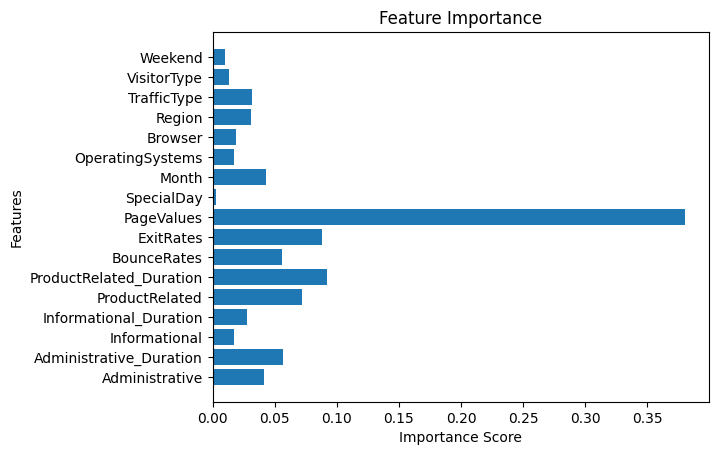

In [ ]:
# ============================================
# 6. FEATURE IMPORTANCE
# ============================================

importances = best_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
# ============================================
# 7. PREDICTION FUNCTION (FOR DEMO)
# ============================================

def predict_customer(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)

    prediction = best_model.predict(input_data)

    if prediction[0] == 1:
        return "Customer WILL Purchase"
    else:
        return "Customer will NOT Purchase"

# Example usage (replace with real values)
# print(predict_customer([values]))

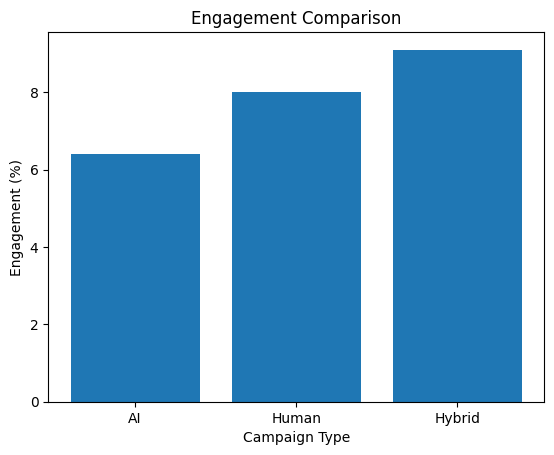

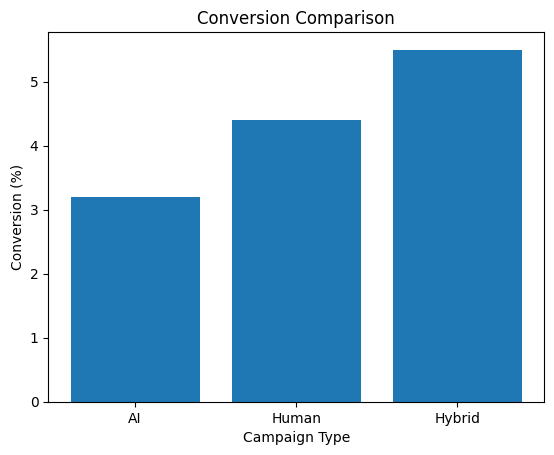

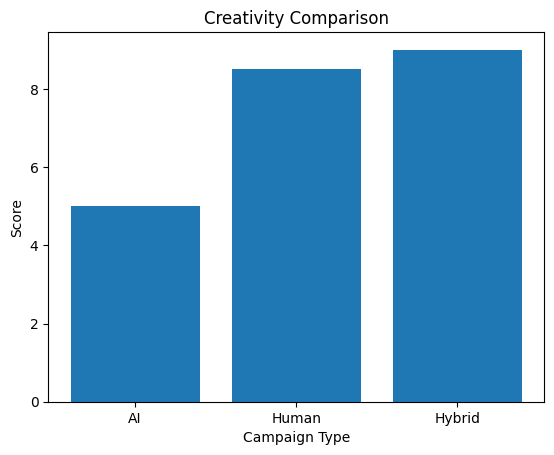

In [ ]:
# ============================================
# 8. VISUALIZATION (FROM YOUR PAPER)
# ============================================

campaigns = ['AI', 'Human', 'Hybrid']
engagement = [6.4, 8.0, 9.1]
conversion = [3.2, 4.4, 5.5]
creativity = [5.0, 8.5, 9.0]

# Engagement
plt.figure()
plt.bar(campaigns, engagement)
plt.title("Engagement Comparison")
plt.xlabel("Campaign Type")
plt.ylabel("Engagement (%)")
plt.show()

# Conversion
plt.figure()
plt.bar(campaigns, conversion)
plt.title("Conversion Comparison")
plt.xlabel("Campaign Type")
plt.ylabel("Conversion (%)")
plt.show()

# Creativity
plt.figure()
plt.bar(campaigns, creativity)
plt.title("Creativity Comparison")
plt.xlabel("Campaign Type")
plt.ylabel("Score")
plt.show()

In [ ]:
# ============================================
# 9. SAVE MODEL
# ============================================

joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\nModel and Scaler saved successfully!")

# ============================================
# DONE
# ============================================


Model and Scaler saved successfully!
